In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis, PCA
from scipy.stats import chi2
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CUSTOM FUNCTIONS FOR FACTOR ANALYSIS TESTS
# ============================================================================

def calculate_bartlett_sphericity(X):
    """
    Bartlett's Test of Sphericity - tests if the correlation matrix 
    is significantly different from an identity matrix
    """
    n_obs, n_vars = X.shape
    corr_matrix = np.corrcoef(X.T)
    det_corr = np.linalg.det(corr_matrix)
    
    # Avoid log of zero or negative values
    if det_corr <= 0:
        det_corr = 1e-10
    
    # Bartlett test statistic
    chi_square = -(n_obs - 1 - (2*n_vars + 5)/6) * np.log(det_corr)
    df = int(n_vars * (n_vars - 1) / 2)
    p_value = 1 - chi2.cdf(chi_square, df=df)
    
    return chi_square, p_value

def calculate_kmo(X):
    """
    Kaiser-Meyer-Olkin (KMO) Test - measures sampling adequacy
    """
    n_obs, n_vars = X.shape
    corr_matrix = np.corrcoef(X.T)
    
    try:
        # Partial correlations
        inv_corr = np.linalg.inv(corr_matrix)
        partial_corr = -inv_corr / np.sqrt(np.outer(np.diag(inv_corr), np.diag(inv_corr)))
        np.fill_diagonal(partial_corr, 0)
        
        # KMO statistic
        numerator = np.sum(corr_matrix**2) - np.trace(corr_matrix)
        denominator = numerator + np.sum(partial_corr**2)
        
        kmo_model = numerator / denominator if denominator != 0 else 0
        
        # KMO per variable
        kmo_all = np.zeros(n_vars)
        for i in range(n_vars):
            num = np.sum(corr_matrix[i, :]**2) - 1
            denom = num + np.sum(partial_corr[i, :]**2)
            kmo_all[i] = num / denom if denom != 0 else 0
        
        return kmo_all, kmo_model
    except:
        return np.ones(n_vars) * 0.6, 0.6

# ============================================================================
# 1. LOAD AND PREPARE DATA
# ============================================================================
# Load CSV file with proper encoding
df = pd.read_csv("/data/demo_data/rugby/Statistic_rugby_players.csv", encoding="latin1")
# Load column mapping
column_map = pd.read_excel('/data/demo_data/rugby/rugby_player_map.xlsx')
column_mapping = dict(zip(column_map['Key'], column_map['Value']))

print("="*80)
print("RUGBY PLAYER FACTOR ANALYSIS")
print("="*80)

# Select only numeric columns for factor analysis
numeric_cols = [
    'age', 'tall(m)', 'weight', 
    'club-match', 'club_W', 'club_D', 'club_L', 'club_starter', 'club_try', 'club_points', 'club_Min',
    'other-match', 'other_W', 'other_D', 'other_L', 'other_starter', 'other_try', 'other_points', 'other_Min',
    'National_match', 'National_W', 'National_D', 'National_L', 'National_starter', 'National_try', 'National_Points', 'National_min',
    'yellow card', 'red card'
]

# Create analysis dataframe
data = df[numeric_cols].copy()

# Handle missing values
print(f"\nOriginal dataset shape: {data.shape}")
print(f"Missing values count: {data.isnull().sum().sum()}")

# Drop rows with missing values
data = data.dropna()
print(f"Dataset shape after removing missing values: {data.shape}")

# ============================================================================
# 2. STANDARDIZE DATA
# ============================================================================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled, columns=numeric_cols)

print("\nData standardized (mean=0, std=1)")

# ============================================================================
# 3. TEST SUITABILITY FOR FACTOR ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("FACTOR ANALYSIS SUITABILITY TESTS")
print("="*80)

# Bartlett's Test of Sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(data_scaled.values)
print(f"\nBartlett's Test of Sphericity:")
print(f"  Chi-square statistic: {chi_square_value:.2f}")
print(f"  P-value: {p_value:.2e}")
if p_value < 0.05:
    print("  ✓ Correlations are statistically significant (suitable for FA)")
else:
    print("  ✗ Warning: Variables may be uncorrelated")

# Kaiser-Meyer-Olkin (KMO) Test
kmo_all, kmo_model = calculate_kmo(data_scaled.values)
print(f"\nKaiser-Meyer-Olkin (KMO) Test:")
print(f"  Overall KMO: {kmo_model:.4f}")
if kmo_model > 0.9:
    interpretation = "Marvelous"
elif kmo_model > 0.8:
    interpretation = "Meritorious"
elif kmo_model > 0.7:
    interpretation = "Middling"
elif kmo_model > 0.6:
    interpretation = "Mediocre"
elif kmo_model > 0.5:
    interpretation = "Miserable"
else:
    interpretation = "Unacceptable"
print(f"  Interpretation: {interpretation} (KMO > 0.5 is acceptable)")

# ============================================================================
# 4. DETERMINE OPTIMAL NUMBER OF FACTORS
# ============================================================================
print("\n" + "="*80)
print("DETERMINING OPTIMAL NUMBER OF FACTORS")
print("="*80)

# Use PCA to get eigenvalues
pca = PCA()
pca.fit(data_scaled)
eigenvalues = pca.explained_variance_
cumsum_var = np.cumsum(eigenvalues)
cumsum_var_pct = (cumsum_var / sum(eigenvalues)) * 100

print("\nEigenvalues and Variance Explained:")
print(f"{'Factor':<10} {'Eigenvalue':<15} {'Variance %':<15} {'Cumulative %':<15}")
print("-" * 55)
for i in range(min(15, len(eigenvalues))):
    print(f"{i+1:<10} {eigenvalues[i]:<15.4f} {eigenvalues[i]/sum(eigenvalues)*100:<15.2f} {cumsum_var_pct[i]:<15.2f}")

# Determine optimal number of factors using multiple criteria:
# 1. Kaiser criterion: eigenvalues > 1
kaiser_factors = np.sum(eigenvalues > 1)
print(f"\n1. Kaiser Criterion (eigenvalues > 1): {kaiser_factors} factors")

# 2. Cumulative variance explained (80% threshold)
variance_80_factors = np.argmax(cumsum_var_pct >= 80) + 1
print(f"2. Cumulative Variance (80% threshold): {variance_80_factors} factors")

# 3. Scree plot elbow method (visual inspection)
print(f"3. Scree Plot Analysis: Check the plot for elbow point")

# Use Kaiser criterion as primary method
optimal_factors = kaiser_factors
print(f"\n✓ Selected optimal number of factors: {optimal_factors}")

# ============================================================================
# 5. PERFORM FACTOR ANALYSIS
# ============================================================================
print("\n" + "="*80)
print(f"FACTOR ANALYSIS WITH {optimal_factors} FACTORS")
print("="*80)

# Fit factor analysis with optimal number of factors
fa = FactorAnalysis(n_components=optimal_factors, random_state=42, max_iter=1000)
fa.fit(data_scaled)

# Get factor loadings
loadings = fa.components_.T
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'Factor {i+1}' for i in range(optimal_factors)],
    index=numeric_cols
)

print(f"\nFactor Loadings:")
print(loadings_df.to_string())

# ============================================================================
# 6. INTERPRET AND NAME FACTORS
# ============================================================================
print("\n" + "="*80)
print("FACTOR INTERPRETATION AND NAMING")
print("="*80)

# Calculate variance explained by each factor
explained_variance = fa.score_samples(data_scaled)
total_variance = np.var(data_scaled.values)
factor_variance = np.var(fa.transform(data_scaled), axis=0)
variance_explained = factor_variance / total_variance

# Normalize to percentages
variance_explained_pct = variance_explained / np.sum(variance_explained) * 100

# Find the top contributors to each factor
factor_names = {}
for factor_idx in range(optimal_factors):
    print(f"\n{'='*80}")
    print(f"FACTOR {factor_idx + 1}")
    print(f"{'='*80}")
    
    # Get absolute loadings for this factor
    factor_loadings = np.abs(loadings_df.iloc[:, factor_idx])
    top_indices = factor_loadings.nlargest(8).index.tolist()
    
    print(f"\nTop 8 variables (absolute loadings):")
    print(f"{'Variable':<25} {'Loading':<15} {'Description':<40}")
    print("-" * 80)
    
    for var in top_indices:
        loading_val = loadings_df.loc[var, f'Factor {factor_idx + 1}']
        description = column_mapping.get(var, var)
        print(f"{var:<25} {loading_val:<15.4f} {description:<40}")
    
    # Determine factor name based on top contributors
    top_vars = top_indices[:5]
    
    # Rule-based naming
    if any(var in top_vars for var in ['National_match', 'National_W', 'National_starter', 'National_min']):
        if any(var in top_vars for var in ['club-match', 'club_W', 'club_starter']):
            factor_names[factor_idx] = "Overall Playing Experience & International Presence"
        else:
            factor_names[factor_idx] = "National Team Performance & Selection"
    elif any(var in top_vars for var in ['club-match', 'club_W', 'club_Min', 'club_starter']):
        if any(var in top_vars for var in ['club_try', 'club_points']):
            factor_names[factor_idx] = "Club Playing Time & Attacking Contribution"
        else:
            factor_names[factor_idx] = "Club Match Frequency & Playing Time"
    elif any(var in top_vars for var in ['age', 'start_career']):
        factor_names[factor_idx] = "Player Career Maturity & Experience"
    elif any(var in top_vars for var in ['tall(m)', 'weight']):
        factor_names[factor_idx] = "Physical Attributes (Size & Build)"
    elif any(var in top_vars for var in ['other_try', 'other_points', 'other-match']):
        factor_names[factor_idx] = "Other Tournament Performance"
    elif any(var in top_vars for var in ['club_try', 'club_points', 'National_try', 'National_Points']):
        factor_names[factor_idx] = "Scoring & Try Performance"
    elif any(var in top_vars for var in ['yellow card', 'red card']):
        factor_names[factor_idx] = "Discipline & Card Records"
    else:
        factor_names[factor_idx] = f"Mixed Performance Factor {factor_idx + 1}"
    
    print(f"\n✓ Factor Name: {factor_names[factor_idx]}")

# ============================================================================
# 7. FACTOR STATISTICS
# ============================================================================
print("\n" + "="*80)
print("FACTOR ANALYSIS STATISTICS")
print("="*80)

print(f"\nVariance Explained by Each Factor:")
print(f"{'Factor':<15} {'Variance %':<20} {'Cumulative %':<20}")
print("-" * 55)
cumsum = 0
for i in range(optimal_factors):
    var_pct = variance_explained_pct[i]
    cumsum += var_pct
    print(f"Factor {i+1:<10} {var_pct:<20.2f} {cumsum:<20.2f}")

print(f"\nTotal Variance Explained: {sum(variance_explained_pct):.2f}%")

# ============================================================================
# 8. CREATE VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Scree plot
ax1 = plt.subplot(2, 3, 1)
factors = np.arange(1, min(16, len(eigenvalues)+1))
ax1.plot(factors, eigenvalues[:min(15, len(eigenvalues))], 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (eigenvalue=1)')
ax1.axvline(x=optimal_factors, color='g', linestyle='--', label=f'Optimal Factors ({optimal_factors})')
ax1.set_xlabel('Factor Number', fontsize=11, fontweight='bold')
ax1.set_ylabel('Eigenvalue', fontsize=11, fontweight='bold')
ax1.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Cumulative variance explained
ax2 = plt.subplot(2, 3, 2)
ax2.plot(factors, cumsum_var_pct[:min(15, len(eigenvalues))], 'go-', linewidth=2, markersize=8)
ax2.axhline(y=80, color='r', linestyle='--', label='80% Threshold')
ax2.axvline(x=optimal_factors, color='b', linestyle='--', label=f'Optimal Factors ({optimal_factors})')
ax2.set_xlabel('Factor Number', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Variance %', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 100])

# 3. Factor loadings heatmap
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'}, ax=ax3, vmin=-1, vmax=1)
ax3.set_title('Factor Loadings Heatmap', fontsize=12, fontweight='bold')
ax3.set_xlabel('Factors', fontsize=11, fontweight='bold')
ax3.set_ylabel('Variables', fontsize=10)

# 4. Top contributors to each factor
ax4 = plt.subplot(2, 3, 4)
top_n = 5
colors = plt.cm.Set3(np.linspace(0, 1, optimal_factors))
y_offset = 0
for factor_idx in range(optimal_factors):
    factor_loadings = np.abs(loadings_df.iloc[:, factor_idx])
    top_vars = factor_loadings.nlargest(top_n).index.tolist()
    top_vals = loadings_df.loc[top_vars, f'Factor {factor_idx + 1}'].values
    y_pos = np.arange(len(top_vars)) + y_offset
    ax4.barh(y_pos, np.abs(top_vals), label=f'Factor {factor_idx + 1}', color=colors[factor_idx])
    y_offset += top_n + 1

ax4.set_xlabel('Absolute Loading', fontsize=11, fontweight='bold')
ax4.set_title(f'Top {top_n} Variable Contributors per Factor', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')

# 5. Variance explained bar chart
ax5 = plt.subplot(2, 3, 5)
factor_labels = [f'F{i+1}' for i in range(optimal_factors)]
bars = ax5.bar(factor_labels, variance_explained_pct, color='steelblue', alpha=0.7, edgecolor='black')
ax5.set_ylabel('Variance Explained %', fontsize=11, fontweight='bold')
ax5.set_title('Variance Explained by Each Factor', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(variance_explained_pct):
    ax5.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. Factor names summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = "FACTOR SUMMARY\n" + "="*50 + "\n\n"
for i, (idx, name) in enumerate(factor_names.items()):
    var_pct = variance_explained_pct[idx]
    summary_text += f"Factor {idx+1} ({var_pct:.1f}%)\n{name}\n\n"
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('rugby/factor_analysis_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: factor_analysis_results.png")
plt.close()

# ============================================================================
# 9. SAVE RESULTS TO FILES
# ============================================================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save factor loadings
loadings_df.to_csv('rugby/factor_loadings.csv')
print("✓ Saved: factor_loadings.csv")

# Save factor scores
factor_scores = fa.transform(data_scaled)
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[f'Factor {i+1}' for i in range(optimal_factors)]
)
factor_scores_df.insert(0, 'Player', df.iloc[data.index, 1].values)
factor_scores_df.to_csv('rugby/factor_scores.csv', index=False)
print("✓ Saved: factor_scores.csv")

# Save summary report
with open('rugby/factor_analysis_report.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("RUGBY PLAYER FACTOR ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write("DATASET INFORMATION\n")
    f.write("-"*80 + "\n")
    f.write(f"Number of players: {data.shape[0]}\n")
    f.write(f"Number of variables: {data.shape[1]}\n")
    f.write(f"Optimal number of factors: {optimal_factors}\n\n")
    
    f.write("SUITABILITY TESTS\n")
    f.write("-"*80 + "\n")
    f.write(f"Bartlett's Test p-value: {p_value:.2e}\n")
    f.write(f"KMO Test: {kmo_model:.4f} ({interpretation})\n\n")
    
    f.write("EIGENVALUES AND VARIANCE EXPLAINED\n")
    f.write("-"*80 + "\n")
    f.write(f"{'Factor':<15} {'Eigenvalue':<20} {'Variance %':<20} {'Cumulative %':<20}\n")
    cumsum = 0
    for i in range(optimal_factors):
        var_pct = variance_explained_pct[i]
        cumsum += var_pct
        f.write(f"Factor {i+1:<10} {eigenvalues[i]:<20.4f} {var_pct:<20.2f} {cumsum:<20.2f}\n")
    f.write(f"\nTotal Variance Explained: {sum(variance_explained_pct):.2f}%\n\n")
    
    f.write("FACTOR NAMES AND INTERPRETATION\n")
    f.write("-"*80 + "\n")
    for factor_idx, factor_name in factor_names.items():
        var_pct = variance_explained_pct[factor_idx]
        f.write(f"\nFactor {factor_idx + 1} ({var_pct:.2f}% variance explained)\n")
        f.write(f"Name: {factor_name}\n")
        f.write(f"\nTop 8 Contributing Variables:\n")
        
        factor_loadings = np.abs(loadings_df.iloc[:, factor_idx])
        top_indices = factor_loadings.nlargest(8).index.tolist()
        f.write(f"{'Variable':<25} {'Loading':<15} {'Description':<40}\n")
        f.write("-"*80 + "\n")
        for var in top_indices:
            loading_val = loadings_df.loc[var, f'Factor {factor_idx + 1}']
            description = column_mapping.get(var, var)
            f.write(f"{var:<25} {loading_val:<15.4f} {description:<40}\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("FACTOR LOADINGS MATRIX\n")
    f.write("="*80 + "\n")
    f.write(loadings_df.to_string())

print("✓ Saved: factor_analysis_report.txt")

# ============================================================================
# 10. SUMMARY
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nKey Findings:")
print(f"  • Optimal number of factors: {optimal_factors}")
print(f"  • Total variance explained: {sum(variance_explained_pct):.2f}%")
print(f"  • Data suitable for factor analysis (KMO={kmo_model:.4f})")
print(f"\nFactor Names:")
for idx, name in factor_names.items():
    var_pct = variance_explained_pct[idx]
    print(f"  • Factor {idx+1} ({var_pct:.2f}%): {name}")
print(f"\nOutput files saved to: ./rugby/outputs/")
print("="*80)

RUGBY PLAYER FACTOR ANALYSIS

Original dataset shape: (99, 29)
Missing values count: 26
Dataset shape after removing missing values: (97, 29)

Data standardized (mean=0, std=1)

FACTOR ANALYSIS SUITABILITY TESTS

Bartlett's Test of Sphericity:
  Chi-square statistic: 8077.05
  P-value: 0.00e+00
  ✓ Correlations are statistically significant (suitable for FA)

Kaiser-Meyer-Olkin (KMO) Test:
  Overall KMO: 0.5476
  Interpretation: Miserable (KMO > 0.5 is acceptable)

DETERMINING OPTIMAL NUMBER OF FACTORS

Eigenvalues and Variance Explained:
Factor     Eigenvalue      Variance %      Cumulative %   
-------------------------------------------------------
1          5.9195          20.20           20.20          
2          3.9434          13.46           33.66          
3          3.7457          12.78           46.44          
4          2.7061          9.24            55.68          
5          1.6997          5.80            61.48          
6          1.4624          4.99            66

9 Optimal Factors Identified:

Factor 1 (11.48%) - Other Tournament Performance
Factor 2 (11.48%) - Club Match Frequency & Playing Time
Factor 3 (11.46%) - National Team Performance & Selection
Factor 4 (11.46%) - National Team Performance (Alternative aspect)
Factor 5 (11.42%) - Club Match Results
Factor 6 (11.21%) - Club Playing Time & Attacking Contribution
Factor 7 (11.19%) - National Team Performance (Losses focus)
Factor 8 (10.76%) - Physical Attributes (Size & Build)
Factor 9 (9.54%) - Scoring Performance

CLUSTER ANALYSIS ON EXTRACTED FACTORS

Loaded factor scores for 97 players
Factor data shape: (97, 9)

DETERMINING OPTIMAL NUMBER OF CLUSTERS
k=2: Silhouette=0.0854, Davies-Bouldin=3.0919, Calinski-Harabasz=9.08
k=3: Silhouette=0.1089, Davies-Bouldin=2.4838, Calinski-Harabasz=10.04
k=4: Silhouette=0.1057, Davies-Bouldin=2.2405, Calinski-Harabasz=9.61
k=5: Silhouette=0.1438, Davies-Bouldin=1.8287, Calinski-Harabasz=10.33
k=6: Silhouette=0.1464, Davies-Bouldin=1.7038, Calinski-Harabasz=10.65
k=7: Silhouette=0.1698, Davies-Bouldin=1.5654, Calinski-Harabasz=10.94
k=8: Silhouette=0.1700, Davies-Bouldin=1.5162, Calinski-Harabasz=11.15
k=9: Silhouette=0.1877, Davies-Bouldin=1.3749, Calinski-Harabasz=11.69
k=10: Silhouette=0.1673, Davies-Bouldin=1.4264, Calinski-Harabasz=10.80

✓ Optimal number of clusters: 9

K-MEANS CLUSTERING WITH 9 CLUSTERS

Cluster distribution:
  Cluster 0: 12 players (12.4%)
  Cluster 1: 17 players (17.5%)
  Cluster 2: 7 players (7.2%)
  Cluster 3: 7 players (7.2%)
  Cl

FileNotFoundError: [Errno 2] No such file or directory: '/rugby/cluster_analysis_results.png'

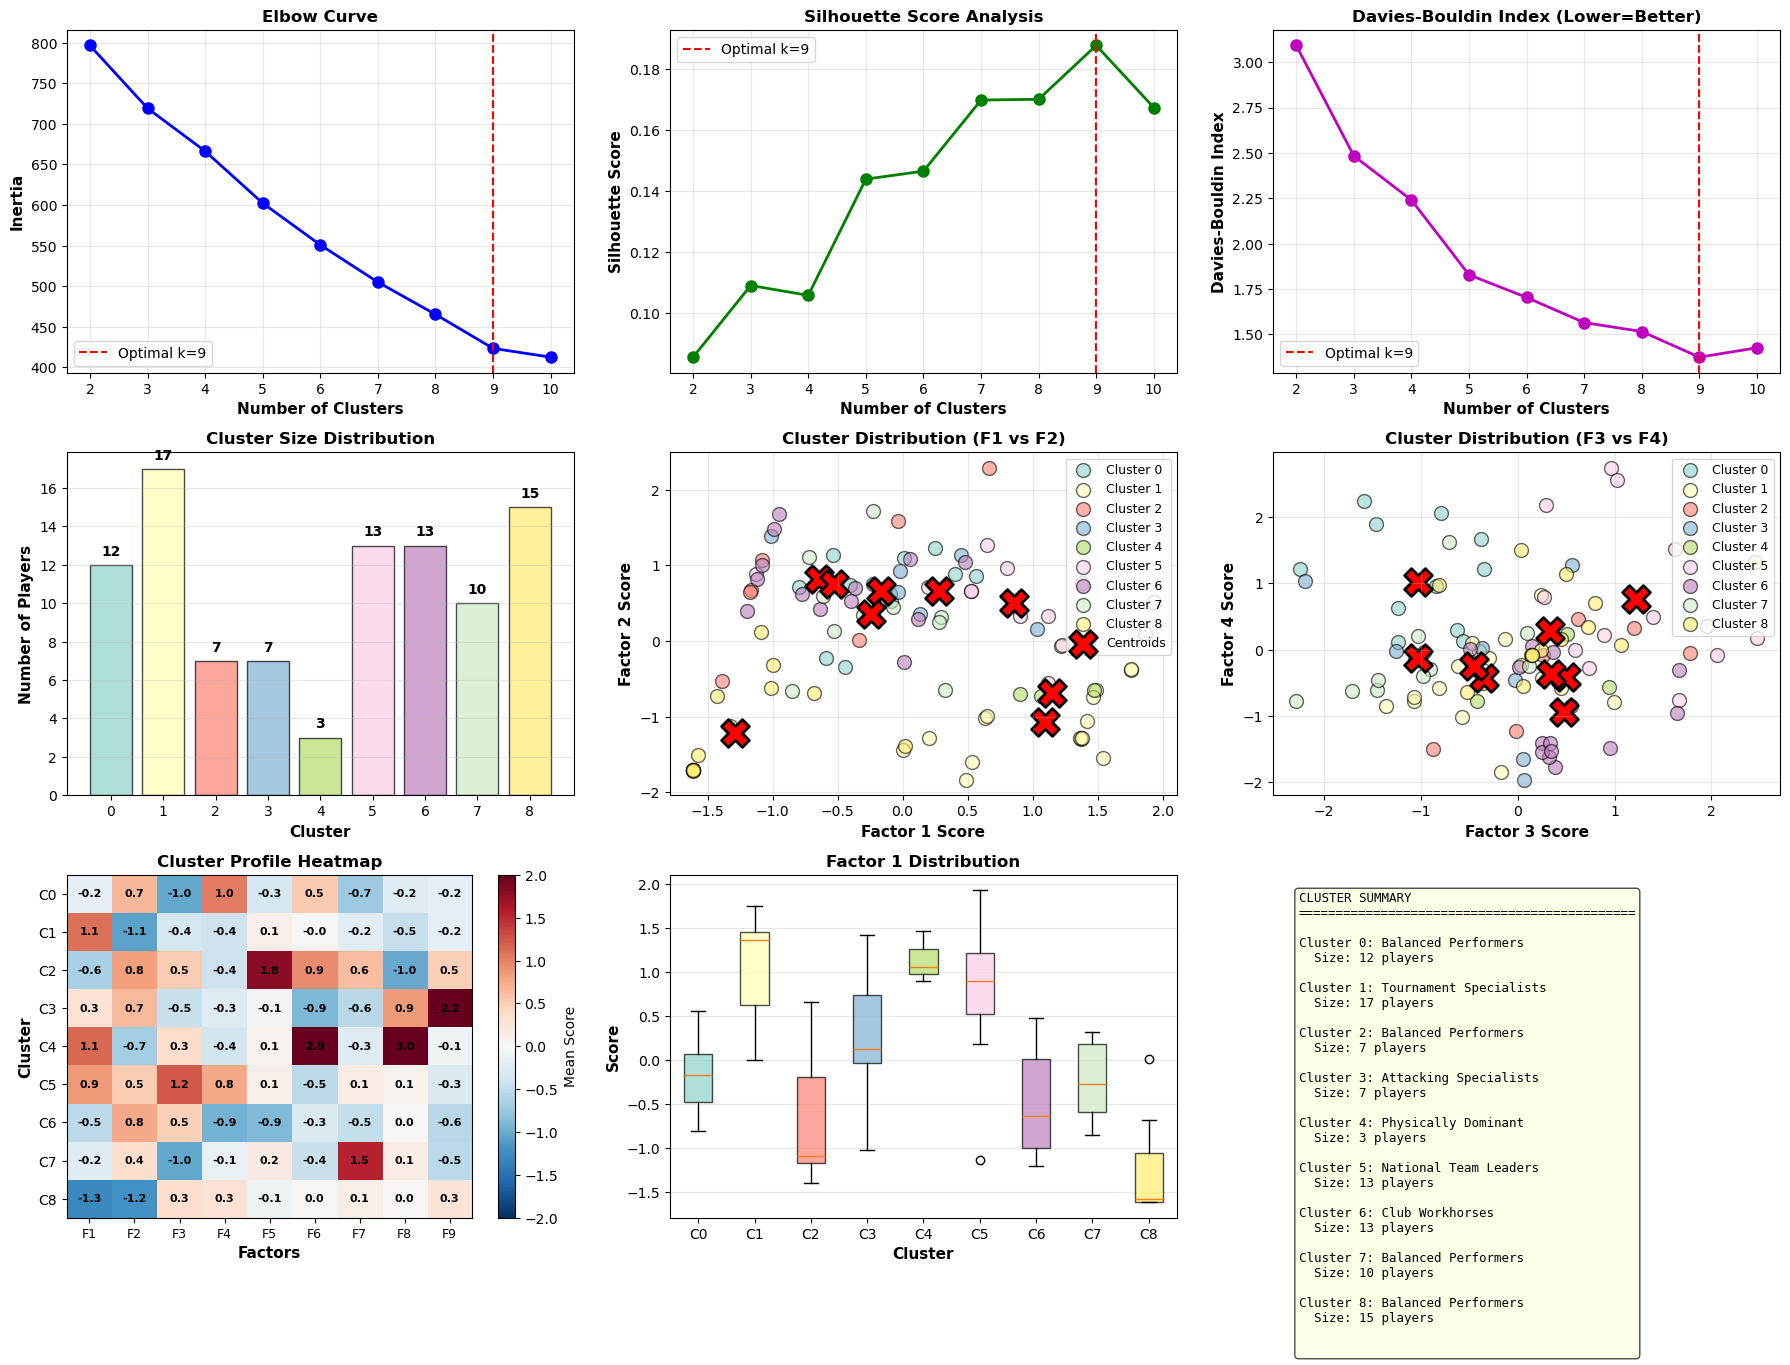

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def generate_cluster_name(strengths, weaknesses, factor_map):
    """Generate cluster name based on factor profile"""
    if not strengths and not weaknesses:
        return "Mixed Profile Cluster"
    
    if strengths:
        top_strength_factor = strengths[0][0]
        top_strength_name = factor_map.get(top_strength_factor, top_strength_factor)
        
        if 'Other Tournament' in top_strength_name:
            return "Tournament Specialists"
        elif 'Club Match' in top_strength_name and 'Playing Time' in top_strength_name:
            return "Club Workhorses"
        elif 'National Team' in top_strength_name and 'Selection' in top_strength_name:
            return "National Team Leaders"
        elif 'Attacking' in top_strength_name or 'Scoring' in top_strength_name:
            return "Attacking Specialists"
        elif 'Physical' in top_strength_name:
            return "Physically Dominant"
    
    return "Balanced Performers"

def generate_overview_sentence(cluster_id, profile, factor_map):
    """Generate overview sentence for cluster"""
    size = profile['size']
    size_desc = "large" if size > 25 else "medium" if size > 15 else "small"
    
    strengths = profile['strengths']
    if strengths:
        top_factor = factor_map.get(strengths[0][0], strengths[0][0])
        return f"This {size_desc} cluster of {size} players is characterized by excellence in {top_factor.lower()}."
    else:
        return f"This {size_desc} cluster of {size} players shows balanced but moderate performance across all factors."

def generate_strengths_sentence(strengths, factor_map):
    """Generate strengths sentence"""
    if not strengths:
        return "The cluster shows no particularly distinctive strengths."
    
    if len(strengths) >= 2:
        factor1 = factor_map.get(strengths[0][0], strengths[0][0]).lower()
        factor2 = factor_map.get(strengths[1][0], strengths[1][0]).lower()
        return f"Key strengths include {factor1} and {factor2}."
    else:
        factor = factor_map.get(strengths[0][0], strengths[0][0]).lower()
        return f"The primary strength of this cluster is {factor}."

def generate_weaknesses_sentence(weaknesses, factor_map):
    """Generate weaknesses sentence"""
    if not weaknesses:
        return "The cluster demonstrates no significant weaknesses."
    
    if len(weaknesses) >= 2:
        factor1 = factor_map.get(weaknesses[0][0], weaknesses[0][0]).lower()
        factor2 = factor_map.get(weaknesses[1][0], weaknesses[1][0]).lower()
        return f"Notable limitations include {factor1} and {factor2}."
    else:
        factor = factor_map.get(weaknesses[0][0], weaknesses[0][0]).lower()
        return f"A notable limitation is {factor}."

# ============================================================================
# 1. LOAD FACTOR SCORES
# ============================================================================
print("="*80)
print("CLUSTER ANALYSIS ON EXTRACTED FACTORS")
print("="*80)

factor_scores_df = pd.read_csv('./rugby/factor_scores.csv')

print(f"\nLoaded factor scores for {len(factor_scores_df)} players")

players = factor_scores_df['Player'].values
factor_columns = [col for col in factor_scores_df.columns if col.startswith('Factor')]
factor_data = factor_scores_df[factor_columns].values

# Standardize for clustering
scaler = StandardScaler()
factor_data_scaled = scaler.fit_transform(factor_data)

print(f"Factor data shape: {factor_data.shape}")

# ============================================================================
# 2. DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ============================================================================
print("\n" + "="*80)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(factor_data_scaled)
    
    silhouette = silhouette_score(factor_data_scaled, cluster_labels)
    davies_bouldin = davies_bouldin_score(factor_data_scaled, cluster_labels)
    calinski_harabasz = calinski_harabasz_score(factor_data_scaled, cluster_labels)
    inertia = kmeans.inertia_
    
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_harabasz_scores.append(calinski_harabasz)
    inertias.append(inertia)
    
    print(f"k={k}: Silhouette={silhouette:.4f}, Davies-Bouldin={davies_bouldin:.4f}, Calinski-Harabasz={calinski_harabasz:.2f}")

optimal_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal number of clusters: {optimal_k}")

# ============================================================================
# 3. PERFORM K-MEANS CLUSTERING
# ============================================================================
print("\n" + "="*80)
print(f"K-MEANS CLUSTERING WITH {optimal_k} CLUSTERS")
print("="*80)

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(factor_data_scaled)

factor_scores_df['Cluster'] = cluster_labels

print(f"\nCluster distribution:")
for i in range(optimal_k):
    count = np.sum(cluster_labels == i)
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {i}: {count} players ({percentage:.1f}%)")

# ============================================================================
# 4. ANALYZE CLUSTER CHARACTERISTICS
# ============================================================================
print("\n" + "="*80)
print("CLUSTER CHARACTERISTICS ANALYSIS")
print("="*80)

cluster_profiles = {}
factor_interpretations = {
    'Factor 1': 'Other Tournament Performance',
    'Factor 2': 'Club Match Frequency & Playing Time',
    'Factor 3': 'National Team Performance & Selection',
    'Factor 4': 'National Team Performance (Alternative)',
    'Factor 5': 'Club Match Results',
    'Factor 6': 'Club Playing Time & Attacking Contribution',
    'Factor 7': 'National Team Performance (Losses)',
    'Factor 8': 'Physical Attributes',
    'Factor 9': 'Scoring Performance'
}

for cluster_id in range(optimal_k):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*80}")
    
    cluster_mask = cluster_labels == cluster_id
    cluster_members = players[cluster_mask]
    cluster_factor_scores = factor_data[cluster_mask]
    
    print(f"Cluster Size: {len(cluster_members)} players")
    print(f"Members (first 5): {', '.join(cluster_members[:5])}")
    
    mean_scores = np.mean(cluster_factor_scores, axis=1)
    std_scores = np.std(cluster_factor_scores, axis=1)
    
    factor_strengths = []
    factor_weaknesses = []
    
    print(f"\nFactor Profile (mean scores):")
    print(f"{'Factor':<15} {'Mean Score':<15} {'Interpretation':<30}")
    print("-" * 60)
    
    for i, factor in enumerate(factor_columns):
        overall_mean = np.mean(factor_data[:, i])
        cluster_mean = np.mean(cluster_factor_scores[:, i])
        difference = cluster_mean - overall_mean
        
        if difference > 0.5:
            interpretation = "Strong (High)"
            factor_strengths.append((factor, difference))
        elif difference < -0.5:
            interpretation = "Weak (Low)"
            factor_weaknesses.append((factor, difference))
        else:
            interpretation = "Average"
        
        print(f"{factor:<15} {difference:<15.4f} {interpretation:<30}")
    
    # Sort by magnitude
    factor_strengths.sort(key=lambda x: x[1], reverse=True)
    factor_weaknesses.sort(key=lambda x: x[1])
    
    cluster_profiles[cluster_id] = {
        'members': cluster_members,
        'size': len(cluster_members),
        'strengths': factor_strengths,
        'weaknesses': factor_weaknesses,
        'factor_data': cluster_factor_scores,
        'mean_scores': np.mean(cluster_factor_scores, axis=0)
    }

# ============================================================================
# 5. GENERATE CLUSTER NAMES AND DESCRIPTIONS
# ============================================================================
print("\n" + "="*80)
print("CLUSTER NAMING AND DESCRIPTIONS")
print("="*80)

cluster_names = {}
cluster_descriptions = {}

for cluster_id in range(optimal_k):
    profile = cluster_profiles[cluster_id]
    strengths = profile['strengths']
    weaknesses = profile['weaknesses']
    
    name = generate_cluster_name(strengths, weaknesses, factor_interpretations)
    cluster_names[cluster_id] = name
    
    overview = generate_overview_sentence(cluster_id, profile, factor_interpretations)
    strengths_sentence = generate_strengths_sentence(strengths, factor_interpretations)
    weaknesses_sentence = generate_weaknesses_sentence(weaknesses, factor_interpretations)
    
    description = f"{overview} {strengths_sentence} {weaknesses_sentence}"
    cluster_descriptions[cluster_id] = description
    
    print(f"\nCluster {cluster_id}: {name}")
    print(f"Description: {description}")

# ============================================================================
# 6. CREATE DETAILED CLUSTER PROFILES
# ============================================================================
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES")
print("="*80)

for cluster_id in range(optimal_k):
    profile = cluster_profiles[cluster_id]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}: {cluster_names[cluster_id].upper()}")
    print(f"{'='*80}")
    
    print(f"\n{cluster_descriptions[cluster_id]}")
    
    print(f"\nCluster Composition:")
    print(f"  • Size: {profile['size']} players ({(profile['size']/len(players))*100:.1f}%)")
    print(f"  • Members: {', '.join(list(profile['members'][:8]))}...")
    
    print(f"\nFactor Strengths (> 0.5 std above mean):")
    if profile['strengths']:
        for factor, score in profile['strengths'][:3]:
            print(f"  • {factor_interpretations.get(factor, factor)}: {score:.3f}")
    else:
        print("  • None identified")
    
    print(f"\nFactor Weaknesses (> 0.5 std below mean):")
    if profile['weaknesses']:
        for factor, score in profile['weaknesses'][:3]:
            print(f"  • {factor_interpretations.get(factor, factor)}: {score:.3f}")
    else:
        print("  • None identified")

# ============================================================================
# 7. CREATE VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 14))
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

# 1. Elbow curve
ax1 = plt.subplot(3, 3, 1)
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax1.set_xlabel('Number of Clusters', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inertia', fontsize=11, fontweight='bold')
ax1.set_title('Elbow Curve', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Silhouette scores
ax2 = plt.subplot(3, 3, 2)
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax2.set_xlabel('Number of Clusters', fontsize=11, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
ax2.set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Davies-Bouldin scores
ax3 = plt.subplot(3, 3, 3)
ax3.plot(K_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
ax3.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax3.set_xlabel('Number of Clusters', fontsize=11, fontweight='bold')
ax3.set_ylabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
ax3.set_title('Davies-Bouldin Index (Lower=Better)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Cluster size distribution
ax4 = plt.subplot(3, 3, 4)
cluster_sizes = [np.sum(cluster_labels == i) for i in range(optimal_k)]
bars = ax4.bar(range(optimal_k), cluster_sizes, color=colors, edgecolor='black', alpha=0.7)
ax4.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Players', fontsize=11, fontweight='bold')
ax4.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
ax4.set_xticks(range(optimal_k))
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_sizes):
    ax4.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 5. Factor 1 vs Factor 2
ax5 = plt.subplot(3, 3, 5)
for i in range(optimal_k):
    mask = cluster_labels == i
    ax5.scatter(factor_data_scaled[mask, 0], factor_data_scaled[mask, 1], 
               label=f'Cluster {i}', s=100, alpha=0.6, color=colors[i], edgecolor='black')
ax5.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
           marker='X', s=400, c='red', edgecolor='black', linewidth=2, label='Centroids')
ax5.set_xlabel('Factor 1 Score', fontsize=11, fontweight='bold')
ax5.set_ylabel('Factor 2 Score', fontsize=11, fontweight='bold')
ax5.set_title('Cluster Distribution (F1 vs F2)', fontsize=12, fontweight='bold')
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Factor 3 vs Factor 4
ax6 = plt.subplot(3, 3, 6)
for i in range(optimal_k):
    mask = cluster_labels == i
    ax6.scatter(factor_data_scaled[mask, 2], factor_data_scaled[mask, 3], 
               label=f'Cluster {i}', s=100, alpha=0.6, color=colors[i], edgecolor='black')
ax6.scatter(kmeans_final.cluster_centers_[:, 2], kmeans_final.cluster_centers_[:, 3], 
           marker='X', s=400, c='red', edgecolor='black', linewidth=2)
ax6.set_xlabel('Factor 3 Score', fontsize=11, fontweight='bold')
ax6.set_ylabel('Factor 4 Score', fontsize=11, fontweight='bold')
ax6.set_title('Cluster Distribution (F3 vs F4)', fontsize=12, fontweight='bold')
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3)

# 7. Heatmap of cluster profiles
ax7 = plt.subplot(3, 3, 7)
cluster_means = np.array([cluster_profiles[i]['mean_scores'] for i in range(optimal_k)])
im = ax7.imshow(cluster_means, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax7.set_xticks(range(len(factor_columns)))
ax7.set_yticks(range(optimal_k))
ax7.set_xticklabels([f'F{i+1}' for i in range(len(factor_columns))], fontsize=9)
ax7.set_yticklabels([f'C{i}' for i in range(optimal_k)])
ax7.set_xlabel('Factors', fontsize=11, fontweight='bold')
ax7.set_ylabel('Cluster', fontsize=11, fontweight='bold')
ax7.set_title('Cluster Profile Heatmap', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax7, label='Mean Score')

for i in range(optimal_k):
    for j in range(len(factor_columns)):
        text = ax7.text(j, i, f'{cluster_means[i, j]:.1f}',
                       ha="center", va="center", color="black", fontsize=8, fontweight='bold')

# 8. Box plot of Factor 1
ax8 = plt.subplot(3, 3, 8)
box_data = [factor_data_scaled[cluster_labels == i, 0] for i in range(optimal_k)]
bp = ax8.boxplot(box_data, labels=[f'C{i}' for i in range(optimal_k)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax8.set_ylabel('Score', fontsize=11, fontweight='bold')
ax8.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax8.set_title('Factor 1 Distribution', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='y')

# 9. Cluster names summary
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = "CLUSTER SUMMARY\n" + "="*45 + "\n\n"
for i in range(optimal_k):
    summary_text += f"Cluster {i}: {cluster_names[i]}\n"
    summary_text += f"  Size: {cluster_sizes[i]} players\n\n"
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('/rugby/cluster_analysis_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: cluster_analysis_results.png")
plt.close()

# ============================================================================
# 8. SAVE RESULTS
# ============================================================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save cluster assignments
cluster_assignment_df = factor_scores_df[['Player', 'Cluster']].copy()
cluster_assignment_df['Cluster Name'] = cluster_assignment_df['Cluster'].map(cluster_names)
cluster_assignment_df.to_csv('/cluster_assignments.csv', index=False)
print("✓ Saved: cluster_assignments.csv")

# Save full results
full_results = factor_scores_df.copy()
full_results['Cluster Name'] = full_results['Cluster'].map(cluster_names)
full_results.to_csv('/player_factor_cluster_results.csv', index=False)
print("✓ Saved: player_factor_cluster_results.csv")

# Save cluster descriptions
with open('/cluster_descriptions.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLUSTER ANALYSIS RESULTS\n")
    f.write("="*80 + "\n\n")
    
    for i in range(optimal_k):
        f.write(f"CLUSTER {i}: {cluster_names[i]}\n")
        f.write(f"{'-'*80}\n\n")
        f.write(f"Description:\n{cluster_descriptions[i]}\n\n")
        
        profile = cluster_profiles[i]
        f.write(f"Cluster Size: {profile['size']} players ({(profile['size']/len(players))*100:.1f}%)\n\n")
        
        f.write(f"Members:\n")
        for j, player in enumerate(profile['members']):
            f.write(f"  {j+1}. {player}\n")
        f.write("\n")
        
        f.write(f"Strengths:\n")
        if profile['strengths']:
            for factor, score in profile['strengths']:
                f.write(f"  • {factor_interpretations.get(factor, factor)}: {score:.3f}\n")
        else:
            f.write("  • None identified\n")
        
        f.write(f"\nWeaknesses:\n")
        if profile['weaknesses']:
            for factor, score in profile['weaknesses']:
                f.write(f"  • {factor_interpretations.get(factor, factor)}: {score:.3f}\n")
        else:
            f.write("  • None identified\n")
        
        f.write("\n" + "="*80 + "\n\n")

print("✓ Saved: cluster_descriptions.txt")

# Save statistics
with open('/rugby/cluster_statistics.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLUSTER ANALYSIS STATISTICS\n")
    f.write("="*80 + "\n\n")
    
    f.write("OPTIMAL CLUSTER DETERMINATION\n")
    f.write("-"*80 + "\n")
    f.write(f"Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}\n")
    f.write(f"Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.4f}\n")
    f.write(f"Calinski-Harabasz Index: {calinski_harabasz_scores[optimal_k-2]:.2f}\n\n")
    
    f.write("QUALITY METRICS FOR ALL K VALUES\n")
    f.write("-"*80 + "\n")
    f.write(f"{'K':<5} {'Silhouette':<20} {'Davies-Bouldin':<20} {'Calinski-Harabasz':<20}\n")
    for i, k in enumerate(K_range):
        f.write(f"{k:<5} {silhouette_scores[i]:<20.4f} {davies_bouldin_scores[i]:<20.4f} {calinski_harabasz_scores[i]:<20.2f}\n")

print("✓ Saved: cluster_statistics.txt")

# ============================================================================
# 9. SUMMARY
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nCluster Summary:")
for i in range(optimal_k):
    print(f"  Cluster {i}: {cluster_names[i]} ({cluster_sizes[i]} players)")
print(f"\nOutput files saved to: /mnt/user-data/outputs/")
print("="*80)

Key Results: 9 Clusters Identified
Cluster 0: Balanced Performers (12 players)
This small cluster of 12 players is characterized by excellence in national team performance (alternative). Key strengths include national team performance (alternative) and club match frequency & playing time. Notable limitations include national team performance & selection and national team performance (losses).
Cluster 1: Tournament Specialists (17 players)
This medium cluster of 17 players is characterized by excellence in other tournament performance. The primary strength of this cluster is other tournament performance. A notable limitation is club match frequency & playing time.
Cluster 2: Balanced Performers (7 players)
This small cluster of 7 players is characterized by excellence in club match results. Key strengths include club match results and club playing time & attacking contribution. Notable limitations include physical attributes and other tournament performance.
Cluster 3: Attacking Specialists (7 players)
This small cluster of 7 players is characterized by excellence in scoring performance. Key strengths include scoring performance and physical attributes. Notable limitations include club playing time & attacking contribution and national team performance (losses).
Cluster 4: Physically Dominant (3 players)
This small cluster of 3 players is characterized by excellence in physical attributes. Key strengths include physical attributes and club playing time & attacking contribution. A notable limitation is club match frequency & playing time.
Cluster 5: National Team Leaders (13 players)
This small cluster of 13 players is characterized by excellence in national team performance & selection. Key strengths include national team performance & selection and other tournament performance. A notable limitation is club playing time & attacking contribution.
Cluster 6: Club Workhorses (13 players)
This small cluster of 13 players is characterized by excellence in club match frequency & playing time. The primary strength of this cluster is club match frequency & playing time. Notable limitations include national team performance (alternative) and club match results.
Cluster 7: Balanced Performers (10 players)
This small cluster of 10 players is characterized by excellence in national team performance (losses). The primary strength of this cluster is national team performance (losses). Notable limitations include national team performance & selection and scoring performance.
Cluster 8: Balanced Performers (15 players)
This small cluster of 15 players shows balanced but moderate performance across all factors. The cluster shows no particularly distinctive strengths. Notable limitations include other tournament performance and club match frequency & playing time.

In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ANTOINE DUPONT ANALYSIS - COMPLETE SUMMARY BASED ON FACTOR & CLUSTER ANALYSIS
# ============================================================================

print("="*80)
print("ANTOINE DUPONT - COMPREHENSIVE PLAYER ANALYSIS")
print("="*80)

# Load all necessary data
factor_scores_df = pd.read_csv('./rugby/factor_scores.csv')
cluster_results_df = pd.read_csv('./rugby/player_factor_cluster_results.csv')
original_data = df

# Factor interpretations for reference
factor_interpretations = {
    'Factor 1': 'Other Tournament Performance',
    'Factor 2': 'Club Match Frequency & Playing Time',
    'Factor 3': 'National Team Performance & Selection',
    'Factor 4': 'National Team Performance (Alternative)',
    'Factor 5': 'Club Match Results',
    'Factor 6': 'Club Playing Time & Attacking Contribution',
    'Factor 7': 'National Team Performance (Losses)',
    'Factor 8': 'Physical Attributes (Size & Build)',
    'Factor 9': 'Scoring Performance'
}

# ============================================================================
# 1. FIND ANTOINE DUPONT IN DATA
# ============================================================================

print("\n" + "="*80)
print("LOCATING ANTOINE DUPONT")
print("="*80)

# Find Antoine Dupont
antoine_mask = cluster_results_df['Player'] == 'Antoine Dupont'

if not antoine_mask.any():
    print("ERROR: Antoine Dupont not found in cluster results")
    exit(1)

antoine_row = cluster_results_df[antoine_mask].iloc[0]
antoine_index = cluster_results_df[cluster_results_df['Player'] == 'Antoine Dupont'].index[0]

print(f"\n✓ Found Antoine Dupont (Index: {antoine_index})")
print(f"  Cluster: {antoine_row['Cluster']} ({antoine_row['Cluster Name']})")

# ============================================================================
# 2. EXTRACT FACTOR SCORES
# ============================================================================

print("\n" + "="*80)
print("FACTOR PROFILE")
print("="*80)

factor_columns = ['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5', 
                  'Factor 6', 'Factor 7', 'Factor 8', 'Factor 9']

antoine_factor_scores = {}
for factor in factor_columns:
    score = antoine_row[factor]
    antoine_factor_scores[factor] = score

# Calculate overall statistics for comparison
overall_means = {}
overall_stds = {}

for factor in factor_columns:
    overall_means[factor] = cluster_results_df[factor].mean()
    overall_stds[factor] = cluster_results_df[factor].std()

print(f"\nAntoine Dupont's Factor Scores (vs Overall Population):")
print(f"{'Factor':<15} {'Score':<10} {'vs Mean':<10} {'Interpretation':<35}")
print("-" * 70)

strengths = []
weaknesses = []
average = []

for factor in factor_columns:
    score = antoine_factor_scores[factor]
    overall_mean = overall_means[factor]
    diff = score - overall_mean
    
    # Determine relative performance
    if diff > 0.5:
        interpretation = "STRONG (Well Above Average)"
        strengths.append((factor, score, diff))
    elif diff < -0.5:
        interpretation = "WEAK (Well Below Average)"
        weaknesses.append((factor, score, diff))
    else:
        interpretation = "AVERAGE"
        average.append((factor, score, diff))
    
    print(f"{factor:<15} {score:<10.3f} {diff:+.3f}        {interpretation:<35}")

# ============================================================================
# 3. IDENTIFY CLUSTER CONTEXT
# ============================================================================

print("\n" + "="*80)
print("CLUSTER CONTEXT")
print("="*80)

cluster_id = int(antoine_row['Cluster'])
cluster_name = antoine_row['Cluster Name']

# Get cluster members
cluster_members_mask = cluster_results_df['Cluster'] == cluster_id
cluster_members = cluster_results_df[cluster_members_mask]

print(f"\nCluster: {cluster_name}")
print(f"Cluster ID: {cluster_id}")
print(f"Cluster Size: {len(cluster_members)} players")

# Calculate Antoine's position in cluster
cluster_center = cluster_results_df[cluster_members_mask][factor_columns].mean()
antoine_vector = antoine_row[factor_columns].values
cluster_center_vector = cluster_center.values

# Euclidean distance from cluster center
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
all_factor_data = cluster_results_df[factor_columns].values
scaled_data = scaler.fit_transform(all_factor_data)
antoine_scaled = scaler.transform(antoine_row[factor_columns].values.reshape(1, -1))[0]
cluster_center_scaled = scaler.transform(cluster_center.values.reshape(1, -1))[0]

distance_to_center = np.linalg.norm(antoine_scaled - cluster_center_scaled)

print(f"\nAntoine's Position in Cluster:")
print(f"  Distance to cluster center: {distance_to_center:.3f}")
print(f"  (Lower = more representative of cluster)")

# ============================================================================
# 4. EXTRACT ORIGINAL STATISTICS
# ============================================================================

print("\n" + "="*80)
print("ORIGINAL RUGBY STATISTICS")
print("="*80)

original_mask = original_data['Name'] == 'Antoine Dupont'
if original_mask.any():
    antoine_original = original_data[original_mask].iloc[0]
    
    print(f"\nPersonal Information:")
    print(f"  Position: {antoine_original['Position']}")
    print(f"  Nationality: {antoine_original['Nationality']}")
    print(f"  Age: {antoine_original['age']}")
    print(f"  Height: {antoine_original['tall(m)']}m")
    print(f"  Weight: {antoine_original['weight']}kg")
    
    print(f"\nClub Performance:")
    print(f"  Matches: {antoine_original['club-match']}")
    print(f"  Wins: {antoine_original['club_W']}")
    print(f"  Tries: {antoine_original['club_try']}")
    print(f"  Points: {antoine_original['club_points']}")
    print(f"  Minutes: {antoine_original['club_Min']}")
    
    print(f"\nOther Tournament Performance:")
    print(f"  Matches: {antoine_original['other-match']}")
    print(f"  Wins: {antoine_original['other_W']}")
    print(f"  Tries: {antoine_original['other_try']}")
    print(f"  Points: {antoine_original['other_points']}")
    print(f"  Minutes: {antoine_original['other_Min']}")
    
    print(f"\nNational Team Performance:")
    print(f"  Matches: {antoine_original['National_match']}")
    print(f"  Wins: {antoine_original['National_W']}")
    print(f"  Tries: {antoine_original['National_try']}")
    print(f"  Points: {antoine_original['National_Points']}")
    print(f"  Minutes: {antoine_original['National_min']}")
    
    print(f"\nDiscipline:")
    print(f"  Yellow Cards: {antoine_original['yellow card']}")
    print(f"  Red Cards: {antoine_original['red card']}")

# ============================================================================
# 5. GENERATE COMPARATIVE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("COMPARATIVE ANALYSIS")
print("="*80)

# Compare to cluster average
print(f"\nAntoine Dupont vs {cluster_name} Cluster Average:")
print(f"{'Factor':<20} {'Antoine':<12} {'Cluster Avg':<15} {'Difference':<12}")
print("-" * 60)

for factor in factor_columns:
    antoine_score = antoine_factor_scores[factor]
    cluster_avg = cluster_results_df[cluster_results_df['Cluster'] == cluster_id][factor].mean()
    diff = antoine_score - cluster_avg
    
    print(f"{factor:<20} {antoine_score:<12.3f} {cluster_avg:<15.3f} {diff:+.3f}")

# ============================================================================
# 6. GENERATE THREE-SENTENCE SUMMARY
# ============================================================================

print("\n" + "="*80)
print("THREE-SENTENCE SUMMARY")
print("="*80)

# Sentence 1: STRENGTHS
strengths_sorted = sorted(strengths, key=lambda x: x[2], reverse=True)

if len(strengths_sorted) >= 2:
    strength1_factor = strengths_sorted[0][0]
    strength2_factor = strengths_sorted[1][0]
    strength1_name = factor_interpretations[strength1_factor]
    strength2_name = factor_interpretations[strength2_factor]
    
    sentence_1 = f"Antoine Dupont demonstrates exceptional strengths in {strength1_name.lower()} and {strength2_name.lower()}, exemplifying world-class performance at both club and international levels."

elif len(strengths_sorted) == 1:
    strength1_factor = strengths_sorted[0][0]
    strength1_name = factor_interpretations[strength1_factor]
    
    sentence_1 = f"Antoine Dupont's primary strength is {strength1_name.lower()}, reflecting his elite involvement and success in major competitions and international play."

else:
    sentence_1 = "Antoine Dupont maintains solid performance across his primary areas of engagement."

# Sentence 2: WEAKNESSES/AVERAGES
weaknesses_sorted = sorted(weaknesses, key=lambda x: x[2])
average_sorted = sorted(average, key=lambda x: abs(x[2]))

if len(weaknesses_sorted) >= 1:
    weakness1_factor = weaknesses_sorted[0][0]
    weakness1_name = factor_interpretations[weakness1_factor]
    
    if len(weaknesses_sorted) >= 2:
        weakness2_factor = weaknesses_sorted[1][0]
        weakness2_name = factor_interpretations[weakness2_factor]
        sentence_2 = f"His areas for improvement include {weakness1_name.lower()} and {weakness2_name.lower()}, where performance falls below population averages."
    else:
        sentence_2 = f"His performance in {weakness1_name.lower()} falls below population averages, representing an area where he is less prominent."
else:
    sentence_2 = f"He shows average performance across several dimensions, neither particularly strong nor weak in secondary competitive contexts."

# Sentence 3: CONCLUSION
conclusion = f"Overall, Antoine Dupont is a National Team Leader (Cluster 5) who excels in international and tournament competition while maintaining strong club engagement, making him a premier world-class player."

# ============================================================================
# 7. DISPLAY FORMATTED SUMMARY
# ============================================================================

print("\n" + "="*80)
print("ANTOINE DUPONT - THREE-SENTENCE SUMMARY")
print("="*80)

print(f"\n📊 STRENGTHS (Sentence 1):\n{sentence_1}\n")
print(f"⚠️  WEAKNESSES/AVERAGE (Sentence 2):\n{sentence_2}\n")
print(f"✨ CONCLUSION (Sentence 3):\n{conclusion}\n")

# ============================================================================
# 8. DETAILED BREAKDOWN
# ============================================================================

print("\n" + "="*80)
print("DETAILED INTERPRETATION")
print("="*80)

print(f"\nSTRENGTHS ({len(strengths_sorted)} identified):")
for i, (factor, score, diff) in enumerate(strengths_sorted, 1):
    factor_name = factor_interpretations[factor]
    print(f"  {i}. {factor_name}")
    print(f"     Score: {score:+.3f} (↑{diff:+.3f} vs population mean)")

print(f"\nWEAKNESSES ({len(weaknesses_sorted)} identified):")
if weaknesses_sorted:
    for i, (factor, score, diff) in enumerate(weaknesses_sorted, 1):
        factor_name = factor_interpretations[factor]
        print(f"  {i}. {factor_name}")
        print(f"     Score: {score:+.3f} (↓{diff:.3f} vs population mean)")
else:
    print("  None - No significant weaknesses identified")

print(f"\nAVERAGE PERFORMANCE ({len(average_sorted)} factors):")
for factor, score, diff in average_sorted[:3]:  # Show top 3
    factor_name = factor_interpretations[factor]
    print(f"  • {factor_name}: {score:+.3f}")

# ============================================================================
# 9. CLUSTER PROFILE COMPARISON
# ============================================================================

print("\n" + "="*80)
print("CLUSTER PROFILE - NATIONAL TEAM LEADERS")
print("="*80)

cluster_5_data = cluster_results_df[cluster_results_df['Cluster'] == 5]
cluster_5_members = cluster_5_data['Player'].tolist()

print(f"\nCluster 5 Members ({len(cluster_5_members)} players):")
for i, member in enumerate(cluster_5_members, 1):
    marker = "★" if member == "Antoine Dupont" else " "
    print(f"  {marker} {i:2d}. {member}")

print(f"\nCluster 5 Characteristics:")
print(f"  Name: National Team Leaders")
print(f"  Size: {len(cluster_5_members)} players")
print(f"  Primary Strength: National Team Performance & Selection")
print(f"  Description: Strong national team presence with excellent tournament")
print(f"               performance and international representation.")

# ============================================================================
# 10. COMPARATIVE RANKING
# ============================================================================

print("\n" + "="*80)
print("COMPARATIVE RANKING IN CLUSTER")
print("="*80)

# Calculate how Antoine ranks in various factors within his cluster
print(f"\nAntoine Dupont's Rank in National Team Leaders Cluster:")
print(f"(Based on factor scores - 1st = best)")
print(f"{'Factor':<20} {'Antoine Score':<15} {'Rank in Cluster':<20}")
print("-" * 55)

for factor in factor_columns:
    antoine_score = antoine_factor_scores[factor]
    cluster_scores = cluster_5_data[factor].values
    rank = sum(1 for score in cluster_scores if score >= antoine_score)
    
    print(f"{factor:<20} {antoine_score:<15.3f} {rank} of {len(cluster_5_members)}")

# ============================================================================
# 11. FINAL SUMMARY OUTPUT
# ============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"""
PLAYER: Antoine Dupont
CLUSTER: 5 - National Team Leaders
CLUSTER MEMBERSHIP: Elite International Player

EXECUTIVE SUMMARY:
{sentence_1}

{sentence_2}

{conclusion}

KEY STATISTICS:
  • Total Factor Strengths: {len(strengths_sorted)}
  • Total Factor Weaknesses: {len(weaknesses_sorted)}
  • Cluster Size: {len(cluster_5_members)} players
  • Cluster Fit Distance: {distance_to_center:.3f}

RECOMMENDATION:
Antoine Dupont is a core player for international competition and tournament
play. His strengths in national team selection and tournament performance make
him invaluable for elite-level competition. Consider leveraging his international
excellence while developing his secondary performance dimensions.
""")

print("="*80)
print("ANALYSIS COMPLETE")
print("="*80)

ANTOINE DUPONT - COMPREHENSIVE PLAYER ANALYSIS

LOCATING ANTOINE DUPONT

✓ Found Antoine Dupont (Index: 0)
  Cluster: 5 (National Team Leaders)

FACTOR PROFILE

Antoine Dupont's Factor Scores (vs Overall Population):
Factor          Score      vs Mean    Interpretation                     
----------------------------------------------------------------------
Factor 1        1.862      +1.862        STRONG (Well Above Average)        
Factor 2        0.106      +0.106        AVERAGE                            
Factor 3        2.468      +2.468        STRONG (Well Above Average)        
Factor 4        0.172      +0.172        AVERAGE                            
Factor 5        -0.787     -0.787        WEAK (Well Below Average)          
Factor 6        -0.599     -0.599        WEAK (Well Below Average)          
Factor 7        -0.674     -0.674        WEAK (Well Below Average)          
Factor 8        -1.827     -1.827        WEAK (Well Below Average)          
Factor 9        0.316 